In [23]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

%matplotlib inline

In [24]:
taxi_df = pd.read_parquet('data/yellow_tripdata_2019-01.parquet')
taxi_data = pd.concat([taxi_df,])

In [25]:
taxi_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.50,1.0,N,151,239,1,7.00,0.50,0.5,1.65,0.00,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.60,1.0,N,239,246,1,14.00,0.50,0.5,1.00,0.00,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.00,1.0,N,236,236,1,4.50,0.50,0.5,0.00,0.00,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.00,1.0,N,193,193,2,3.50,0.50,0.5,0.00,0.00,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.00,2.0,N,193,193,2,52.00,0.00,0.5,0.00,0.00,0.3,55.55,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7696612,2,2019-01-31 23:37:20,2019-02-01 00:10:43,NaN,10.24,NaN,None,142,95,0,0.00,2.75,0.0,0.00,5.76,0.3,0.00,NaN,None
7696613,2,2019-01-31 23:28:00,2019-01-31 23:50:50,NaN,12.43,NaN,None,48,213,0,48.80,5.50,0.0,0.00,0.00,0.3,54.60,NaN,None
7696614,2,2019-01-31 23:11:00,2019-01-31 23:46:00,NaN,9.14,NaN,None,159,246,0,51.05,2.75,0.5,0.00,0.00,0.3,54.60,NaN,None
7696615,2,2019-01-31 23:03:00,2019-01-31 23:14:00,NaN,0.00,NaN,None,265,265,0,0.00,0.00,0.5,9.82,0.00,0.3,0.00,NaN,None


In [26]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [27]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
                      'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'total_amount' ]]

In [28]:
taxi_data.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,151,239,1,9.95
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,239,246,1,16.30
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,236,236,1,5.80
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,193,193,2,7.55
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,193,193,2,55.55


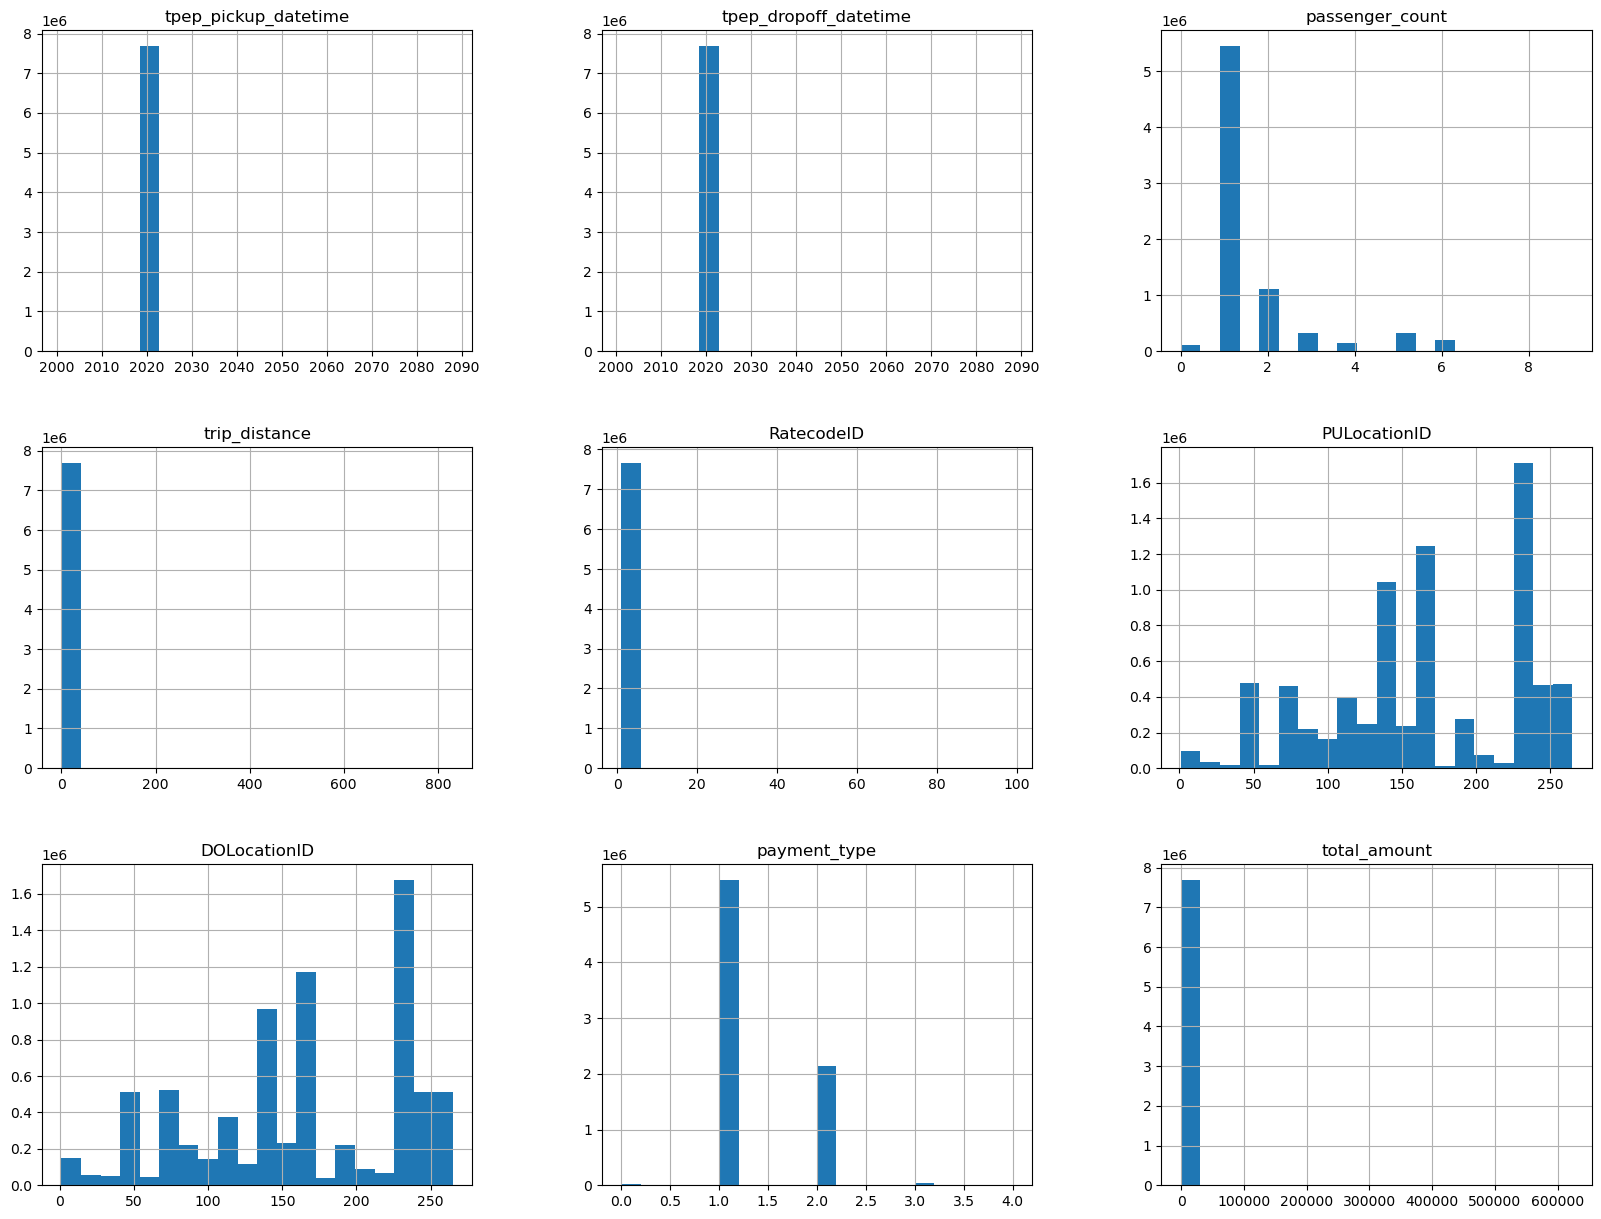

In [32]:
taxi_data.hist( figsize=(20, 15), bins=20 )
plt.show()

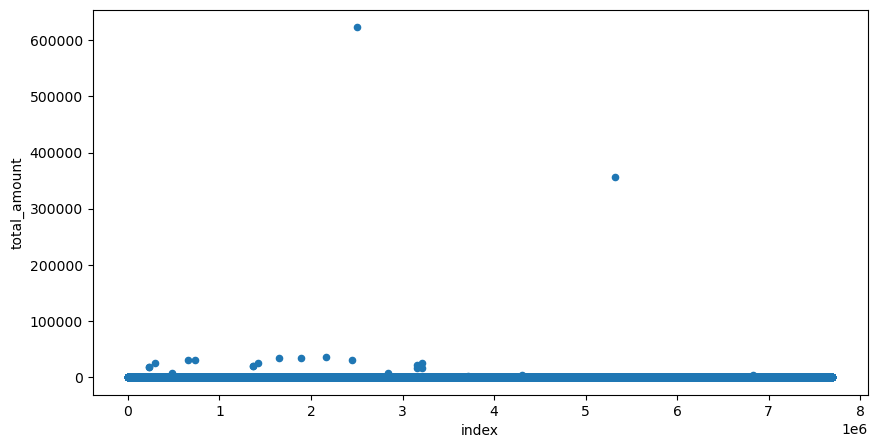

In [93]:
taxi_data.reset_index().plot(kind='scatter', x='index', y='total_amount', figsize=(10, 5))
plt.show()

(23, 9)


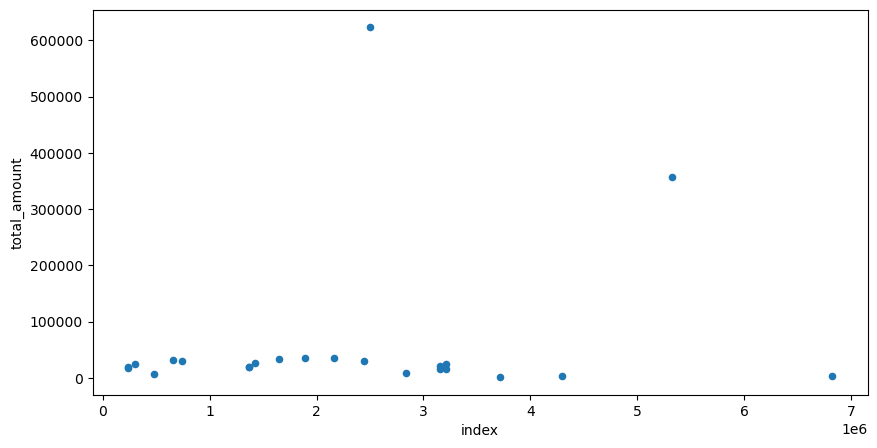

In [61]:
print(taxi_data[taxi_data['total_amount']>1000].shape)
taxi_data[taxi_data['total_amount']>1000].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))
plt.show()

(7696594, 9)


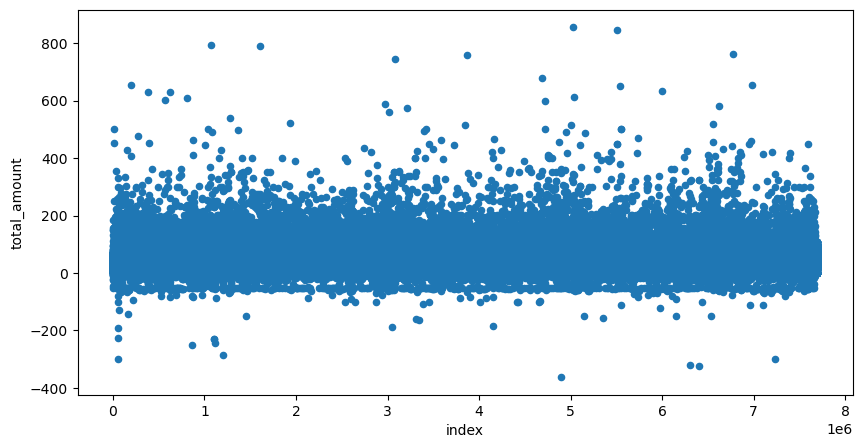

In [62]:
print(taxi_data[taxi_data['total_amount'] < 1000].shape)
taxi_data[taxi_data['total_amount'] < 1000].reset_index().plot(kind='scatter', x='index', y='total_amount', figsize=(10, 5))
plt.show()

(7127, 9)


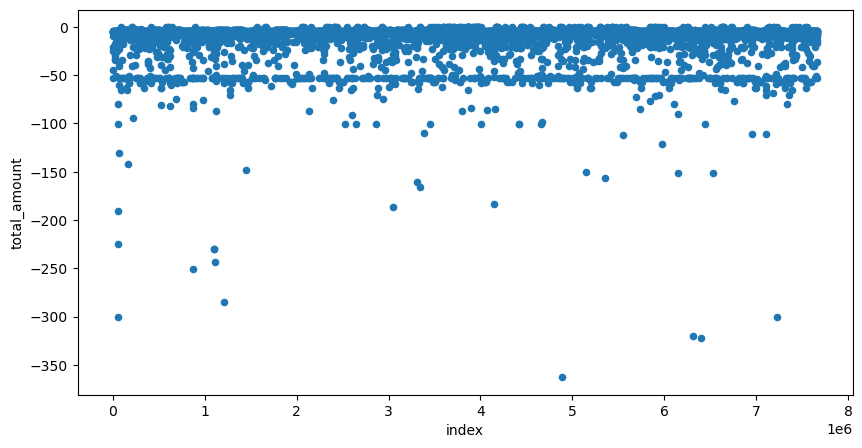

In [63]:
print(taxi_data[taxi_data['total_amount'] < 0].shape)
taxi_data[taxi_data['total_amount'] < 0].reset_index().plot(kind='scatter', x='index', y='total_amount', figsize=(10, 5))
plt.show()

In [65]:
taxi_data[taxi_data['total_amount'] < 0].reset_index().head()

,index,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,148,148,3,-3.8
1,2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,170,238,4,-20.3
2,2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,162,234,4,-9.8
3,2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,234,234,4,-3.8
4,2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,234,234,4,-4.3


In [70]:
taxi_data[taxi_data['total_amount']<0]['payment_type'].to_frame().reset_index()

,index,payment_type
0,663,3
1,2402,4
2,2541,4
3,2544,4
4,2547,4
...,...,...
7122,7665765,3
7123,7666496,3
7124,7666603,3
7125,7666752,4


In [71]:
taxi_data[taxi_data['total_amount']<0]['payment_type'].value_counts()

payment_type
3    4083
4    2667
2     376
1       1
Name: count, dtype: int64

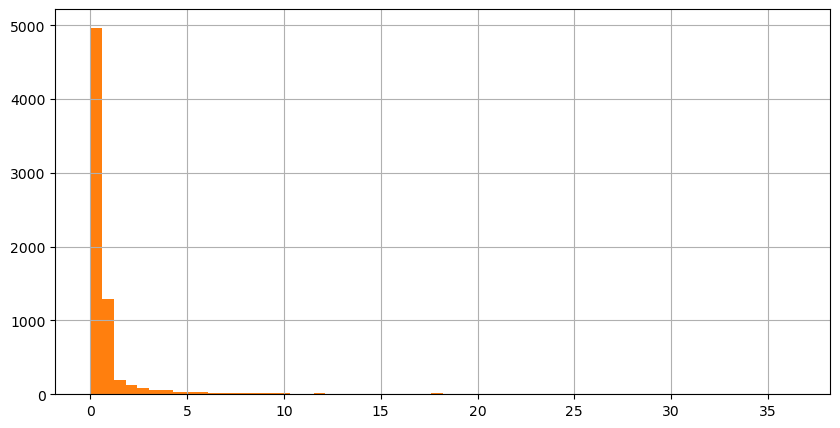

In [73]:
taxi_data[taxi_data['total_amount']<0]['trip_distance'].hist(bins=60, figsize=(10, 5))
plt.show()

In [78]:
print(taxi_data[taxi_data['total_amount'] == 0].shape)
taxi_data[taxi_data['total_amount'] == 0].head()

(1643, 9)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1.0,0.0,5.0,186,264,2,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1.0,0.0,5.0,246,264,2,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1.0,0.0,1.0,193,193,1,0.0
13257,2019-01-01 00:43:34,2019-01-01 00:43:34,1.0,0.0,1.0,7,7,2,0.0
13258,2019-01-01 00:02:52,2019-01-01 00:02:52,1.0,0.0,1.0,264,7,2,0.0


In [80]:
taxi_data[taxi_data['total_amount'] == 0]['payment_type'].value_counts()

payment_type
1    813
2    569
0    231
3     29
4      1
Name: count, dtype: int64

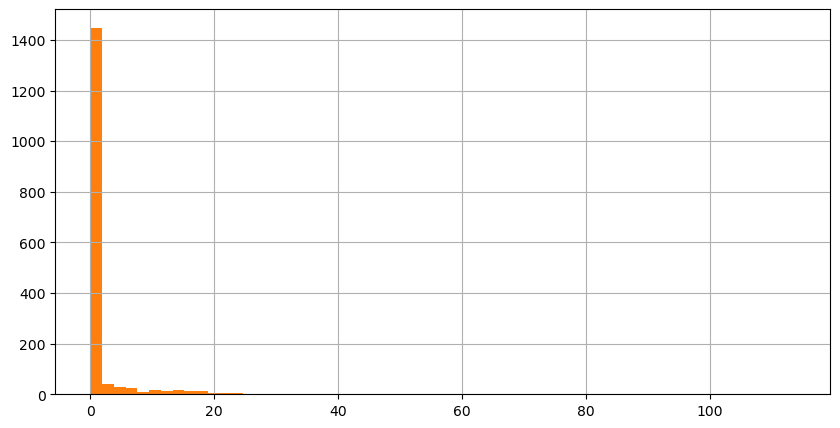

In [82]:
taxi_data[taxi_data['total_amount'] == 0]['trip_distance'].hist(bins=60, figsize=(10, 5))
plt.show()

In [83]:
taxi_data[taxi_data['total_amount'] == 0]['trip_distance'].value_counts()

trip_distance
0.00     1323
0.03        9
0.01        8
0.06        6
1.00        4
         ... 
11.86       1
4.59        1
20.92       1
18.37       1
12.30       1
Name: count, Length: 256, dtype: int64

##### We can safely get rid of the negative values, what about the very high values?

(23, 9)


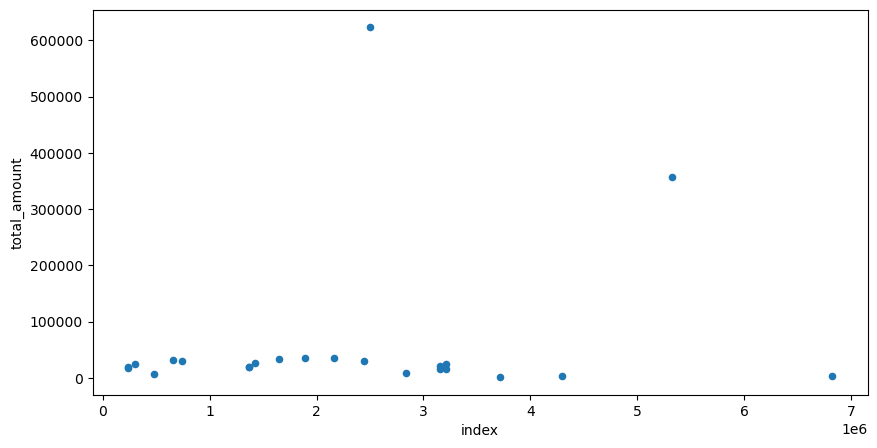

In [86]:
print(taxi_data[taxi_data['total_amount'] > 1000].shape)
taxi_data[taxi_data['total_amount'] > 1000].reset_index().plot(kind='scatter', x='index', y='total_amount', figsize=(10, 5))
plt.show()

In [91]:
taxi_data[taxi_data['total_amount'] > 200].shape

(1166, 9)

In [92]:
taxi_data['total_amount'].mean()

15.810651344610214

##### We can reliably use 200 as our safe cut out value

### Data Cleaning

In [102]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount'] >= 0) & (taxi_data['total_amount'] < 200)].copy()

In [103]:
print(taxi_data.shape)
print(taxi_data_filtered.shape)

(7696617, 9)
(7688319, 9)


##### Checking missing values

In [104]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          28672
trip_distance                0
RatecodeID               28672
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
dtype: int64

In [105]:
taxi_data_filtered['RatecodeID'] = taxi_data_filtered['RatecodeID'].interpolate()

In [109]:
taxi_data_filtered['passenger_count'] = taxi_data_filtered['passenger_count'].interpolate()

In [110]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
dtype: int64

## Data preparation

In [111]:
taxi_data_prepared = taxi_data_filtered.copy()

In [112]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
dtype: object

In [113]:
taxi_data_prepared['tpep_pickup_datetime'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime'])
taxi_data_prepared['tpep_dropoff_datetime'] = pd.to_datetime(taxi_data_prepared['tpep_dropoff_datetime'])

In [119]:
taxi_data_prepared['RatecodeID'] = taxi_data_prepared['RatecodeID'].astype(str)
taxi_data_prepared['PULocationID'] = taxi_data_prepared['PULocationID'].astype(str)
taxi_data_prepared['DOLocationID'] = taxi_data_prepared['DOLocationID'].astype(str)
taxi_data_prepared['payment_type'] = taxi_data_prepared['payment_type'].astype(str)
taxi_data_prepared['passenger_count'] = taxi_data_prepared['passenger_count'].astype('int64')

In [120]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                       object
PULocationID                     object
DOLocationID                     object
payment_type                     object
total_amount                    float64
dtype: object

##### Transforming variables into formats we need

In [121]:
taxi_data_prepared

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.50,1.0,151,239,1,9.95
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.60,1.0,239,246,1,16.30
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.00,1.0,236,236,1,5.80
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.00,1.0,193,193,2,7.55
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.00,2.0,193,193,2,55.55
...,...,...,...,...,...,...,...,...,...
7696612,2019-01-31 23:37:20,2019-02-01 00:10:43,1,10.24,1.0,142,95,0,0.00
7696613,2019-01-31 23:28:00,2019-01-31 23:50:50,1,12.43,1.0,48,213,0,54.60
7696614,2019-01-31 23:11:00,2019-01-31 23:46:00,1,9.14,1.0,159,246,0,54.60
7696615,2019-01-31 23:03:00,2019-01-31 23:14:00,1,0.00,1.0,265,265,0,0.00


In [122]:
taxi_data_prepared['transaction_date'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime'].dt.date)
taxi_data_prepared['transaction_year'] = taxi_data_prepared['tpep_pickup_datetime'].dt.year
taxi_data_prepared['transaction_month'] = taxi_data_prepared['tpep_pickup_datetime'].dt.month
taxi_data_prepared['transaction_day'] = taxi_data_prepared['tpep_pickup_datetime'].dt.day
taxi_data_prepared['transaction_day_name'] = taxi_data_prepared['tpep_pickup_datetime'].dt.day_name()
taxi_data_prepared['transaction_hour'] = taxi_data_prepared['tpep_pickup_datetime'].dt.hour

In [126]:
taxi_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,transaction_date,transaction_year,transaction_month,transaction_day,transaction_day_name,transaction_hour
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1.0,151,239,1,9.95,2019-01-01,2019,1,1,Tuesday,0
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1.0,239,246,1,16.30,2019-01-01,2019,1,1,Tuesday,0
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1.0,236,236,1,5.80,2018-12-21,2018,12,21,Friday,13
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1.0,193,193,2,7.55,2018-11-28,2018,11,28,Wednesday,15
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2.0,193,193,2,55.55,2018-11-28,2018,11,28,Wednesday,15


In [127]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                       object
PULocationID                     object
DOLocationID                     object
payment_type                     object
total_amount                    float64
transaction_date         datetime64[ns]
transaction_year                  int32
transaction_month                 int32
transaction_day                   int32
transaction_day_name             object
transaction_hour                  int32
dtype: object

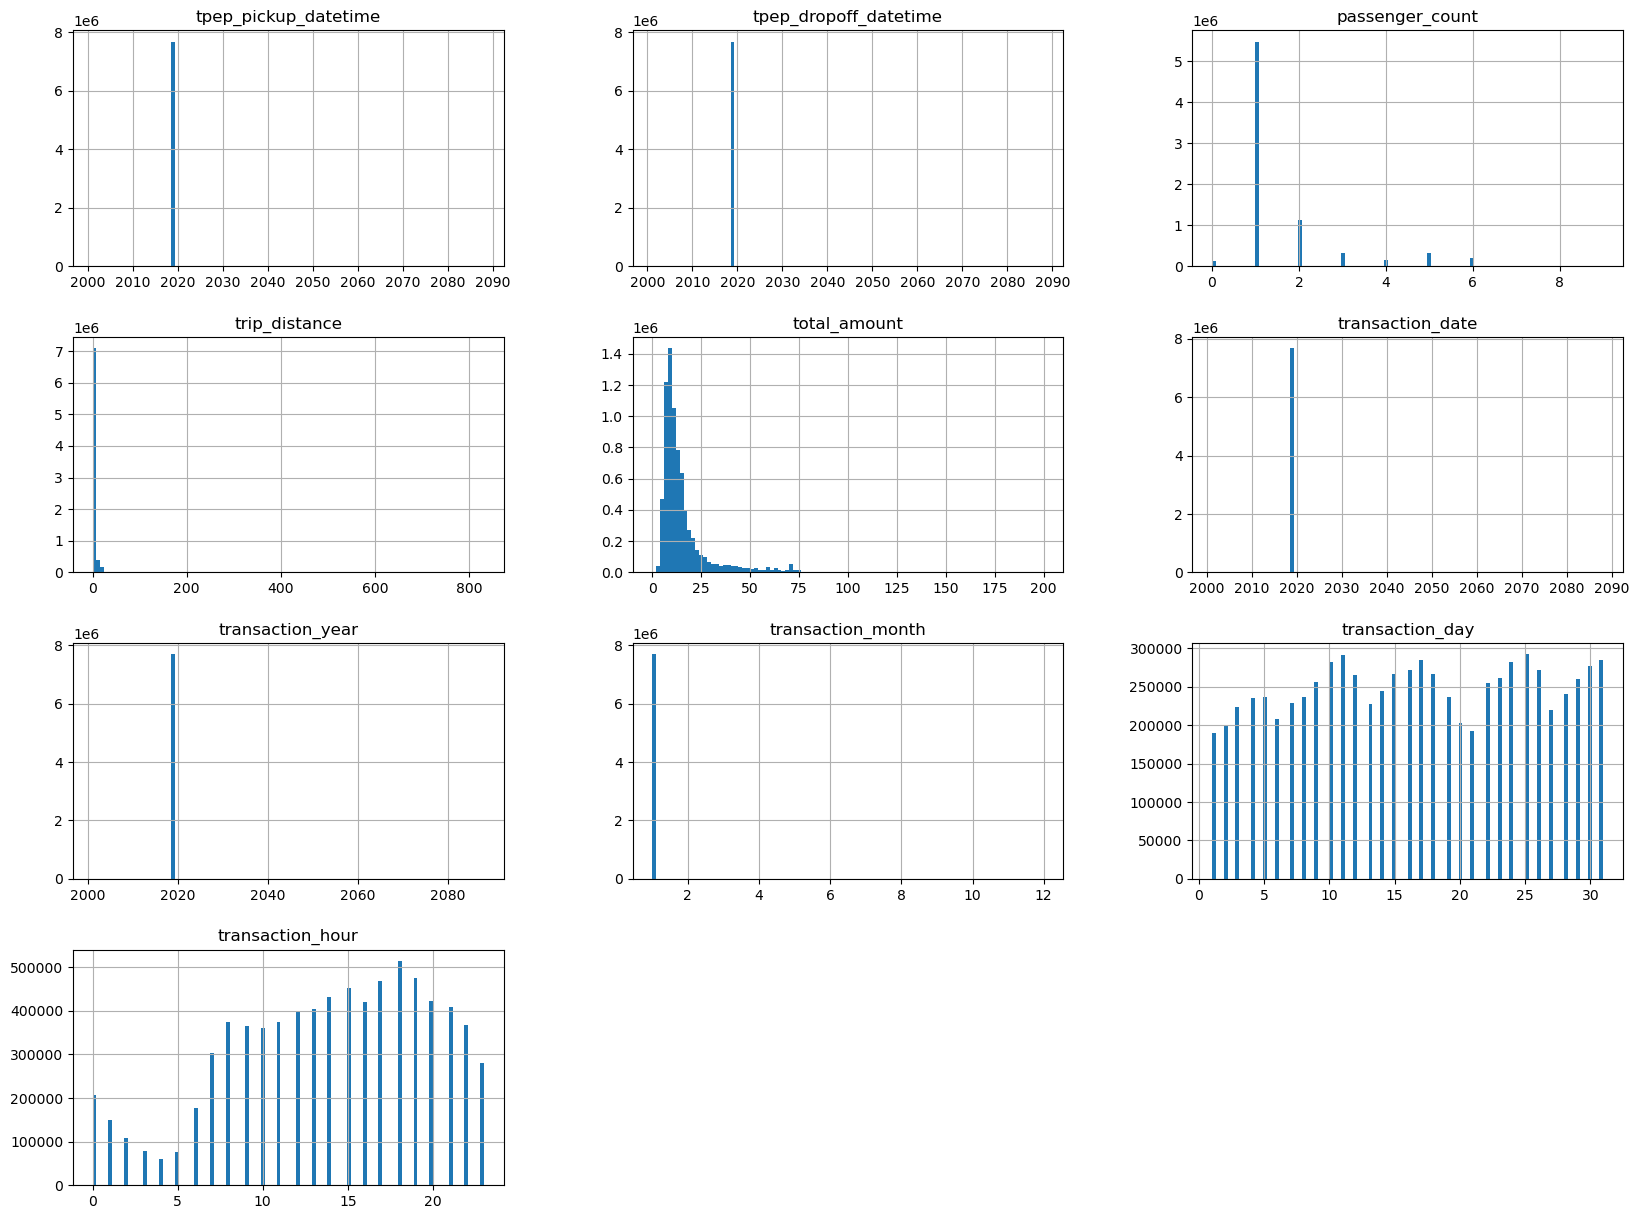

In [131]:
taxi_data_prepared.hist(figsize=(20, 15), bins=100)
plt.show()

In [132]:
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_year'] == 2019]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_month'] == 1]

In [133]:
taxi_data_prepared.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'total_amount', 'transaction_date', 'transaction_year',
       'transaction_month', 'transaction_day', 'transaction_day_name',
       'transaction_hour'],
      dtype='object')

In [134]:
categorical_columns = ['PULocationID', 'transaction_date','transaction_month', 'transaction_day', 
                       'transaction_day_name', 'transaction_hour']

numerical_columns = ['trip_distance', 'total_amount', ]

all_needed_columns = categorical_columns + numerical_columns

In [138]:
main_taxi_df = taxi_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df

(7687783, 8)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_day_name,transaction_hour,trip_distance,total_amount
0,151,2019-01-01,1,1,Tuesday,0,1.50,9.95
1,239,2019-01-01,1,1,Tuesday,0,2.60,16.30
7,163,2019-01-01,1,1,Tuesday,0,1.30,9.05
8,229,2019-01-01,1,1,Tuesday,0,3.70,18.50
9,141,2019-01-01,1,1,Tuesday,0,2.10,13.00
...,...,...,...,...,...,...,...,...
7696612,142,2019-01-31,1,31,Thursday,23,10.24,0.00
7696613,48,2019-01-31,1,31,Thursday,23,12.43,54.60
7696614,159,2019-01-31,1,31,Thursday,23,9.14,54.60
7696615,265,2019-01-31,1,31,Thursday,23,0.00,0.00


In [140]:
taxi_group_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_group_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['total_amount']
print(taxi_group_by_region.shape)
taxi_group_by_region.head()

(102713, 9)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_day_name,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,Tuesday,2,0.0,21.800,1
1,1,2019-01-01,1,1,Tuesday,5,0.0,87.300,1
2,1,2019-01-01,1,1,Tuesday,6,0.0,80.300,1
3,1,2019-01-01,1,1,Tuesday,8,0.0,128.580,2
4,1,2019-01-01,1,1,Tuesday,10,16.9,43.245,4


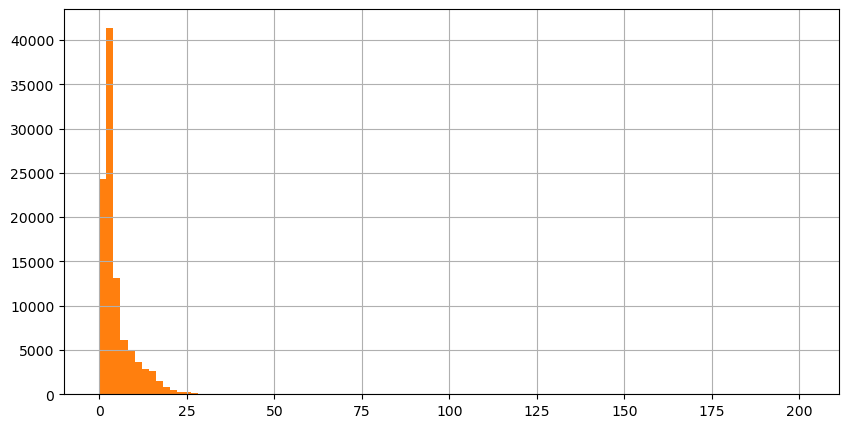

In [142]:
taxi_group_by_region['trip_distance'].hist(bins=100, figsize=(10, 5))
plt.show()

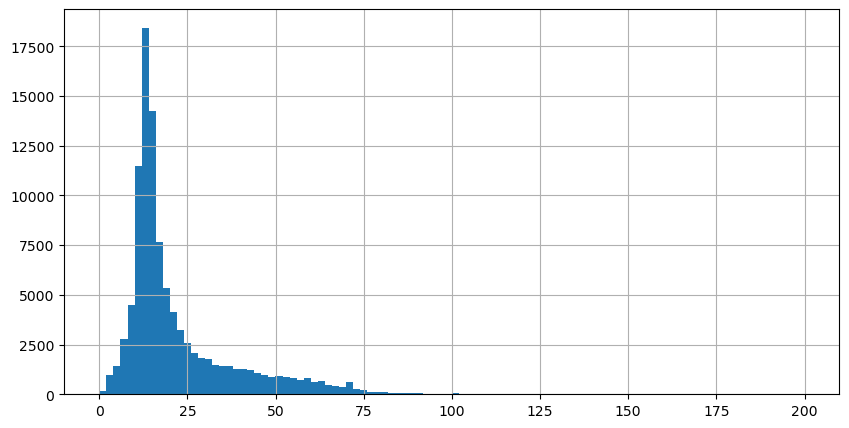

In [143]:
taxi_group_by_region['total_amount'].hist(bins=100, figsize=(10, 5))
plt.show()

### Benchmark Model

In [144]:
data_for_benchmark_model = taxi_group_by_region.copy()

In [163]:
categorical_features_benchmark = ['PULocationID', 'transaction_day', 'transaction_day_name', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark + ['trip_distance']
target_feature_benchmark = 'total_amount'

##### Train-test-split

In [164]:
from sklearn.model_selection import train_test_split

x_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_feature_benchmark]

## one hot encodeing 
X_bench = pd.get_dummies(x_bench)

x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

##### Fit the model

In [165]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(x_train_b, y_train_b)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


##### Model evaluation 

In [166]:
model_at_hand = tree

y_pred_b = model_at_hand.predict(x_test_b)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test_b, y_pred_b)}')
print(f'mean absolute error : {mean_absolute_error(y_test_b, y_pred_b)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test_b, y_pred_b))}') 
print(f'r2 : {r2_score(y_test_b, y_pred_b)}')

mean squared error : 61.824572905323144
mean absolute error : 3.3870518881958755
mean squared error : 7.862860351381242
r2 : 0.7898940321479654


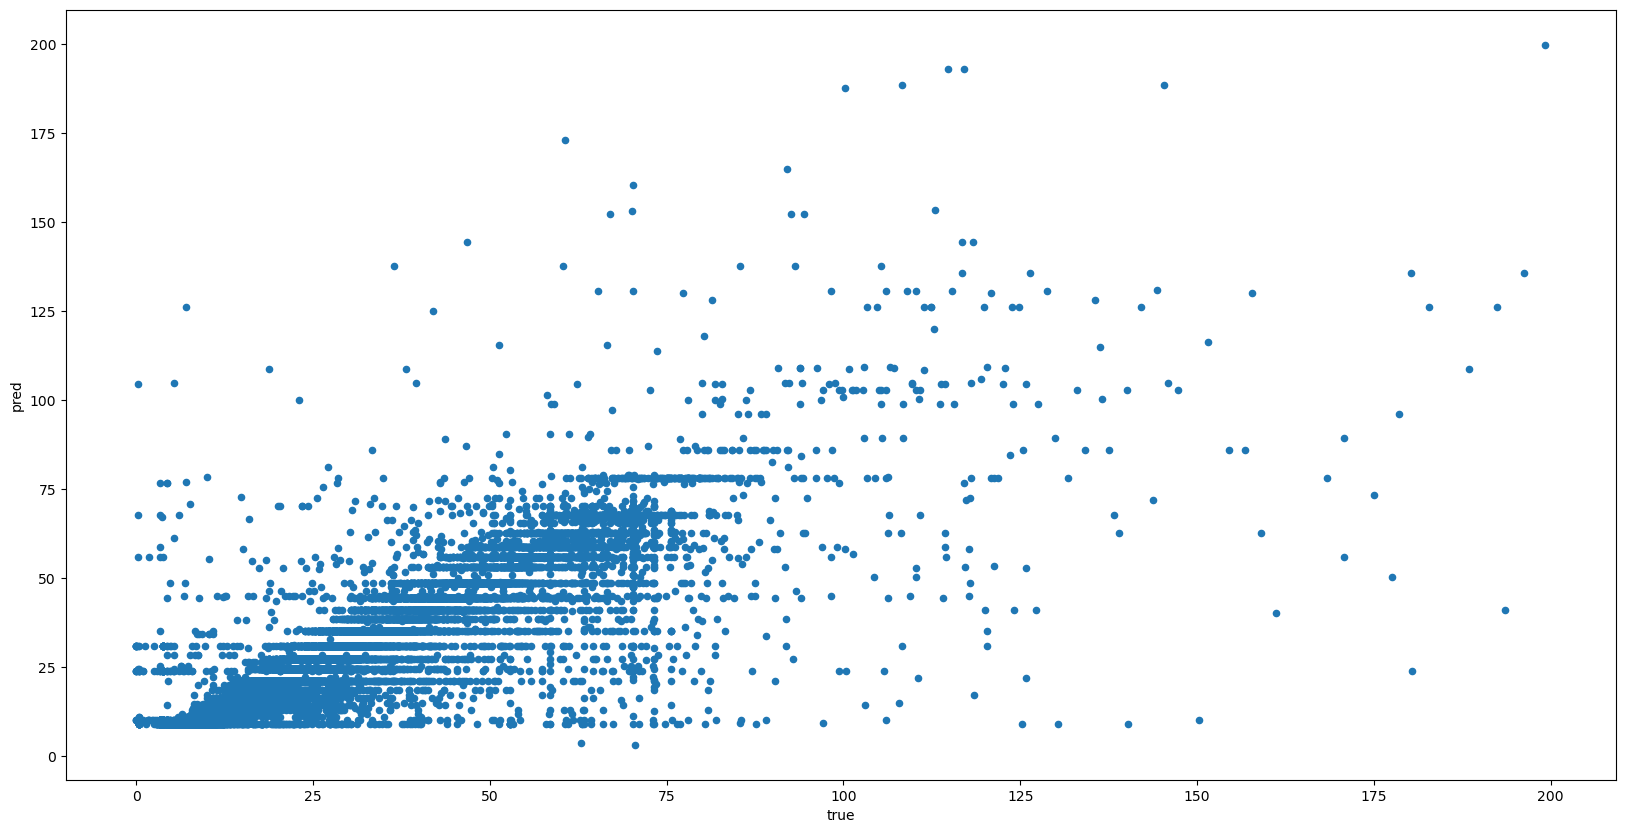

In [167]:
data = {'true': y_test_b, 'pred': y_pred_b}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')
plt.show()

##### Fixing the model

mean squared error : 242.77199666114697
mean absolute error : 10.711482624899025
mean squared error : 15.581142341341566
r2 : 0.17495838743643977


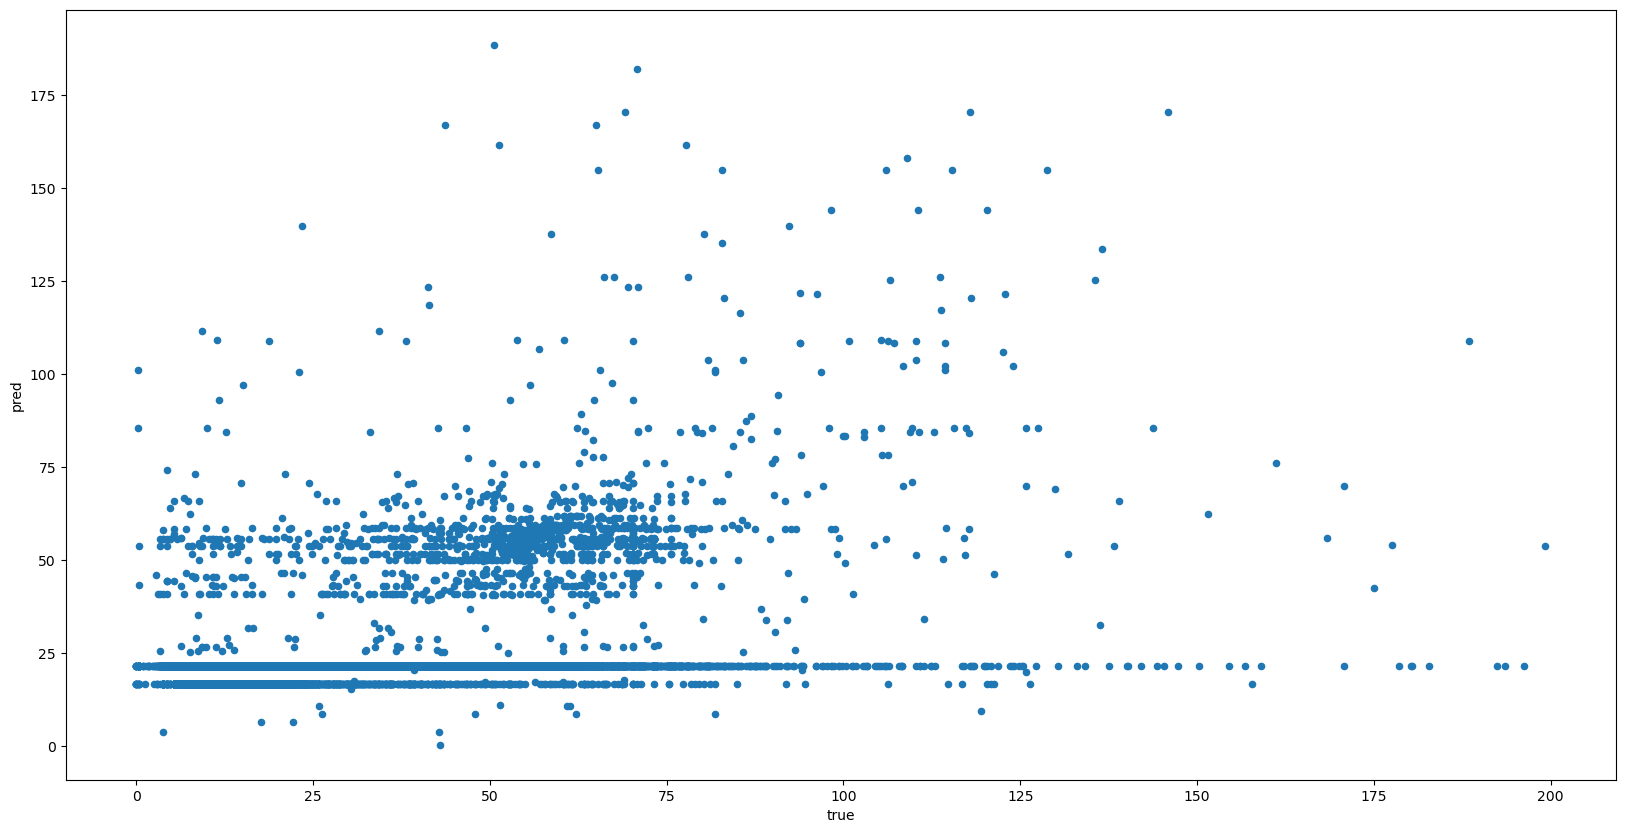

In [175]:
categorical_features_benchmark_b = ['PULocationID', 'transaction_day', 'transaction_day_name', 'transaction_hour']
input_features_benchmark_b = categorical_features_benchmark_b
target_feature_benchmark = 'total_amount'

from sklearn.model_selection import train_test_split

x_bench_bb = data_for_benchmark_model[input_features_benchmark_b]
y_bench_bb = data_for_benchmark_model[target_feature_benchmark]

## one hot encodeing 
X_bench_bb = pd.get_dummies(x_bench_bb)

x_train_bb, x_test_bb, y_train_bb, y_test_bb = train_test_split(X_bench_bb, y_bench_bb, test_size=0.33, random_state=42)

from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(x_train_bb, y_train_bb)

model_at_hand_bb = tree

y_pred_bb = model_at_hand_bb.predict(x_test_bb)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test_bb, y_pred_bb)}')
print(f'mean absolute error : {mean_absolute_error(y_test_bb, y_pred_bb)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test_bb, y_pred_bb))}') 
print(f'r2 : {r2_score(y_test_bb, y_pred_bb)}')

data_bb = {'true': y_test_bb, 'pred': y_pred_bb}
results_bb = pd.DataFrame(data_bb)

results_bb.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')
plt.show()

##### Feature Engineering 

In [176]:
taxi_group_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_day_name,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,Tuesday,2,0.0,21.800,1
1,1,2019-01-01,1,1,Tuesday,5,0.0,87.300,1
2,1,2019-01-01,1,1,Tuesday,6,0.0,80.300,1
3,1,2019-01-01,1,1,Tuesday,8,0.0,128.580,2
4,1,2019-01-01,1,1,Tuesday,10,16.9,43.245,4


In [177]:
data_with_new_features = taxi_group_by_region.copy()

In [179]:
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 or x == 6 else False)

In [181]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018', end='2020').date

holidays_dt = pd.to_datetime(holidays)

data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays_dt)

In [182]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_day_name,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,Tuesday,2,0.0,21.800,1,1,False,True
1,1,2019-01-01,1,1,Tuesday,5,0.0,87.300,1,1,False,True
2,1,2019-01-01,1,1,Tuesday,6,0.0,80.300,1,1,False,True
3,1,2019-01-01,1,1,Tuesday,8,0.0,128.580,2,1,False,True
4,1,2019-01-01,1,1,Tuesday,10,16.9,43.245,4,1,False,True


In [192]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)
zone_lookup.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [193]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')

In [194]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_day_name,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,LocationID,Borough
0,1,2019-01-01,1,1,Tuesday,2,0.0,21.800,1,1,False,True,1,EWR
1,1,2019-01-01,1,1,Tuesday,5,0.0,87.300,1,1,False,True,1,EWR
2,1,2019-01-01,1,1,Tuesday,6,0.0,80.300,1,1,False,True,1,EWR
3,1,2019-01-01,1,1,Tuesday,8,0.0,128.580,2,1,False,True,1,EWR
4,1,2019-01-01,1,1,Tuesday,10,16.9,43.245,4,1,False,True,1,EWR


##### Model Training -Random-forest

In [195]:
data_for_second_model = data_with_new_features.copy()

In [196]:
categorical_features_new = ['PULocationID', 'transaction_day', 'transaction_day_name', 'transaction_hour', 
                            'transaction_week_day', 'weekend', 'is_holiday', 'Borough']
target_feature_new = 'total_amount'

##### Train-test-split

In [206]:
from sklearn.model_selection import train_test_split

x = data_for_second_model[categorical_features_new]
y = data_with_new_features[target_feature_new]

X = pd.get_dummies(x) 

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.33, random_state=42)

In [229]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=15)
tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [230]:
new_model_at_hand = tree

y_pred = new_model_at_hand.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test, y_pred)}')
print(f'mean absolute error : {mean_absolute_error(y_test, y_pred)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test, y_pred))}') 
print(f'r2 : {r2_score(y_test, y_pred)}')


mean squared error : 217.13897042667173
mean absolute error : 8.837326731533965
mean squared error : 14.735636071329656
r2 : 0.2627315143036416


In [231]:
compare_data_1 = {'y_pred': y_pred, 'y_test': y_test}

result = pd.DataFrame(compare_data_1)
result.head()

,y_pred,y_test
15985,13.536087,14.555880
38727,29.945970,50.560000
25717,29.945970,44.020000
102442,19.614391,18.218571
100369,29.945970,25.175000


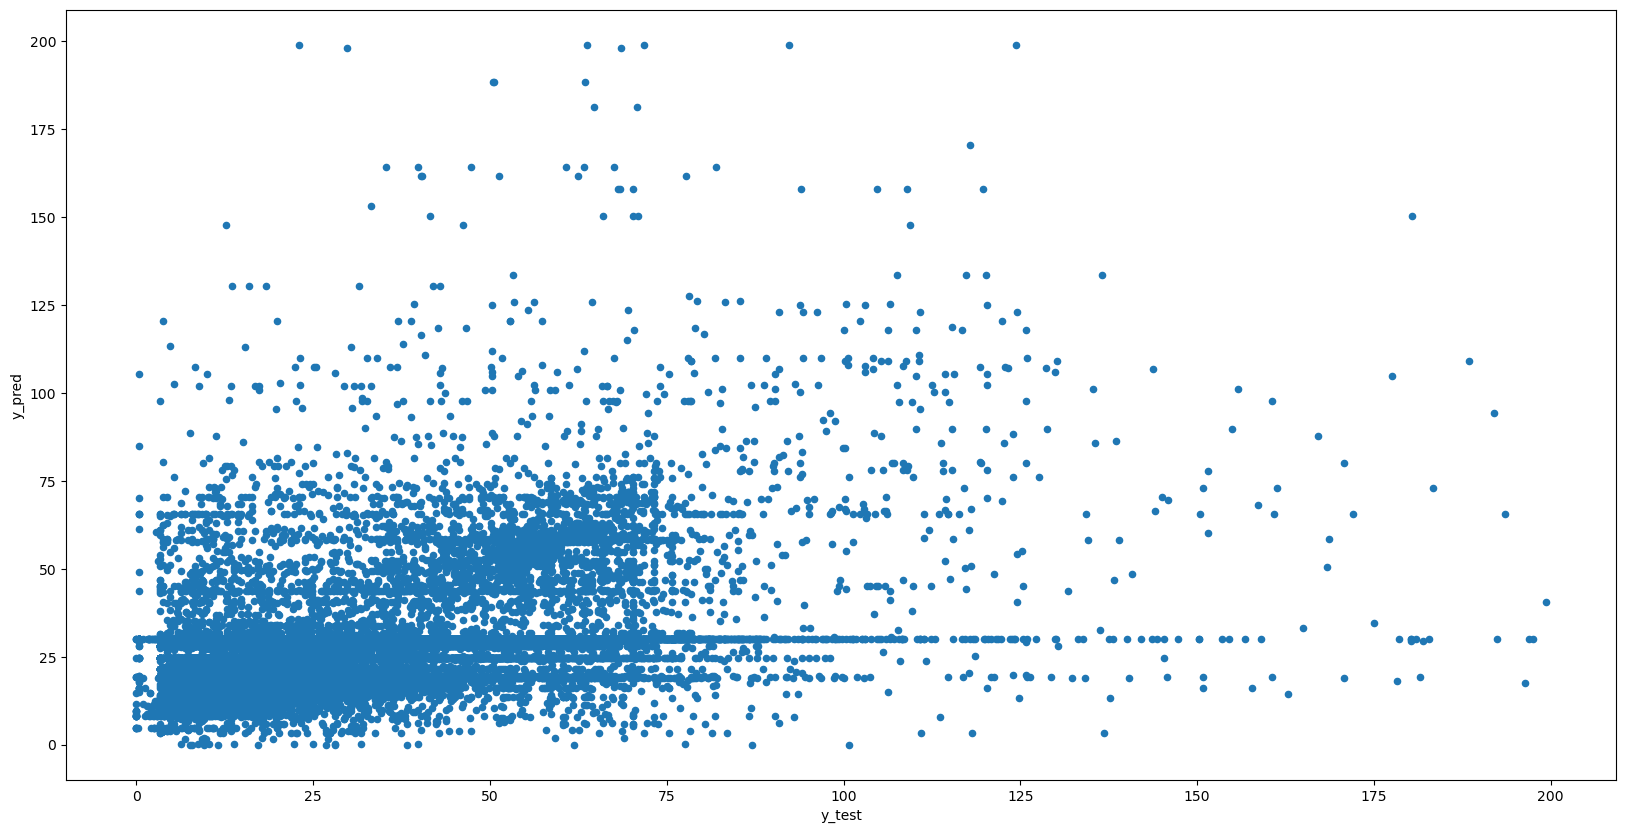

In [232]:
result.plot(kind='scatter', y="y_pred", x="y_test", figsize=(20, 10))
plt.show()

##### Ranndom Forest

In [240]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor()
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [241]:
model_At_hand = random_forest

y_pred1 = model_At_hand.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test, y_pred1)}')
print(f'mean absolute error : {mean_absolute_error(y_test, y_pred1)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test, y_pred1))}') 
print(f'r2 : {r2_score(y_test, y_pred1)}')


mean squared error : 185.46761372917678
mean absolute error : 7.795024254524316
mean squared error : 13.618649482572668
r2 : 0.37026768409586586


           y_pred     y_test
15985   13.536087  14.555880
38727   29.945970  50.560000
25717   29.945970  44.020000
102442  19.614391  18.218571
100369  29.945970  25.175000


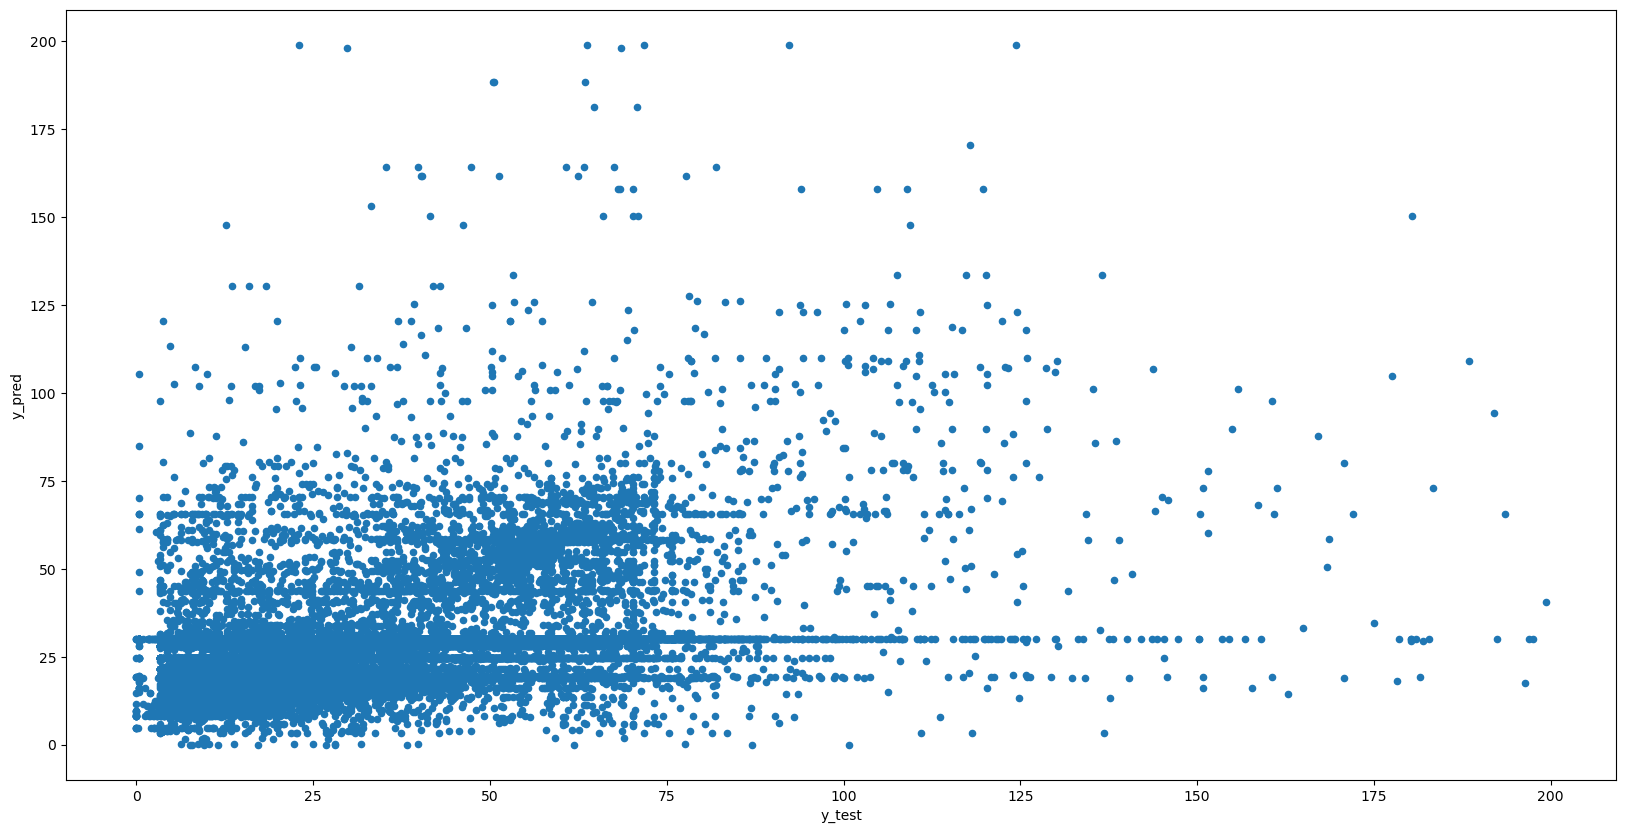

In [242]:
compare_data_2 = {'y_pred': y_pred1, 'y_test': y_test}

result2 = pd.DataFrame(compare_data_1)
print(result2.head())

result2.plot(kind='scatter', x='y_test', y='y_pred', figsize=(20, 10))
plt.show()

##### Now trying Gradient Boosting 

In [243]:
from sklearn.ensemble import GradientBoostingRegressor

grade_boost = GradientBoostingRegressor()
grade_boost.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [244]:
model_At_hand2 = grade_boost

y_pred2 = model_At_hand2.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test, y_pred2)}')
print(f'mean absolute error : {mean_absolute_error(y_test, y_pred2)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test, y_pred2))}') 
print(f'r2 : {r2_score(y_test, y_pred2)}')


mean squared error : 186.52199628072978
mean absolute error : 8.81670953114688
mean squared error : 13.657305601059448
r2 : 0.3666876587065926


           y_pred     y_test
15985   15.419918  14.555880
38727   32.269226  50.560000
25717   27.843421  44.020000
102442  21.879511  18.218571
100369  30.919574  25.175000


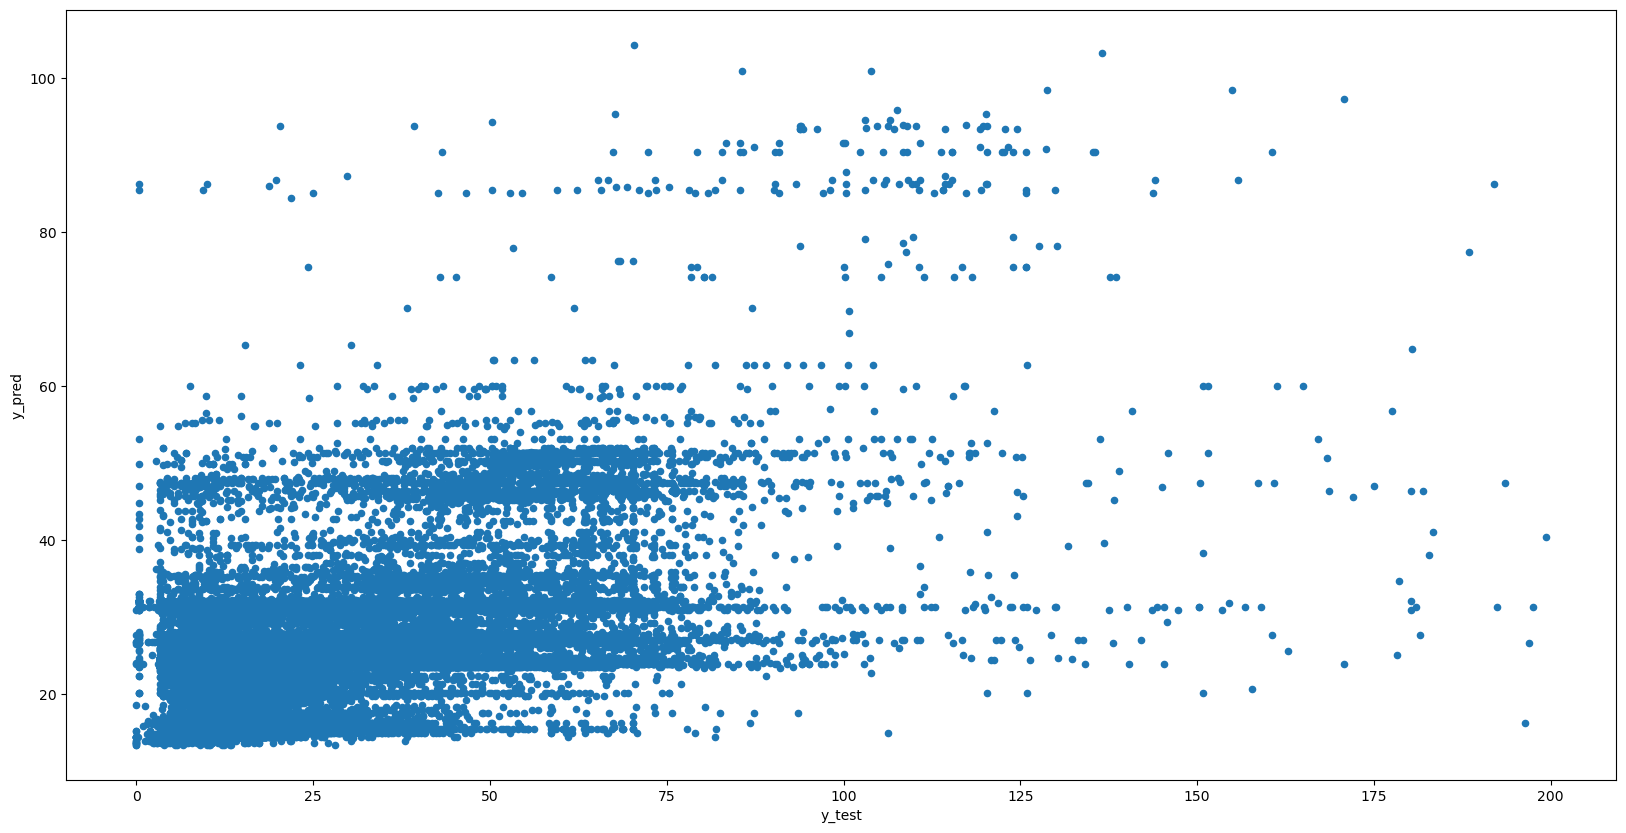

In [263]:
compare_data_2 = {'y_pred': y_pred2, 'y_test': y_test}

result2 = pd.DataFrame(compare_data_2)
print(result2.head())

result2.plot(kind='scatter', x='y_test', y='y_pred', figsize=(20, 10))
plt.show()

##### Tunning the model

In [255]:
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]
max_features = ['auto', 'sqrt']
max_depth = [10, 20, 50, 100, 200, 300, 500]
max_depth.append(None) 
min_samples_split = [2, 5, 10, 20, 40]
min_samples_leaf = [1, 3 ,4, 10, 20] 
bootstrap = [True, False]

In [256]:
import pprint as pp 

random_grid = {
    'n_estimators': n_estimators,       
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,  
    'bootstrap': bootstrap
}

pp.pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 50, 100, 200, 300, 500, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 3, 4, 10, 20],
 'min_samples_split': [2, 5, 10, 20, 40],
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor()

rf_random = RandomizedSearchCV(estimator=rf, param_distributions=random_grid, n_iter=10, cv=3, verbose=2, random_state=42)

rf_random.fit(X_train, y_train)

performance = pd.DataFrame(rf_random.cv_results_)

In [ ]:
performance

In [ ]:
import time
t0 = time.time()

best = RandomForestRegressor(n_estimators=1800, 
                             min_samples_split=2,
                             min_samples_leaf = 4, 
                             max_features = 'sqrt', 
                             max_depth = 300, 
                             bootstrap= True)
best.fit(X_train, y_train)

t1 = time.time() - t0
print('Time elapsed: ', t1, ' seconds')

model_At_hand3 = best
y_pred_3 = model_At_hand3.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test, y_pred_3)}')
print(f'mean absolute error : {mean_absolute_error(y_test, y_pred_3)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test, y_pred_3))}') 
print(f'r2 : {r2_score(y_test, y_pred_3)}')

In [261]:
import time
t0 = time.time()

second_best = RandomForestRegressor(n_estimators=200, 
                             min_samples_split=2,
                             min_samples_leaf = 4, 
                             max_features = 'sqrt', 
                             max_depth = 150, 
                             bootstrap= True)
second_best.fit(X_train, y_train)

t1 = time.time() - t0
print('Time elapsed: ', t1, ' seconds')

model_At_hand3 = second_best
y_pred_3 = model_At_hand3.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print(f'mean squared error : {mean_squared_error(y_test, y_pred_3)}')
print(f'mean absolute error : {mean_absolute_error(y_test, y_pred_3)}')
print(f'mean squared error : {sqrt(mean_squared_error(y_test, y_pred_3))}') 
print(f'r2 : {r2_score(y_test, y_pred_3)}')

Time elapsed:  20.634087324142456  seconds
mean squared error : 168.84055589763292
mean absolute error : 7.8267137782708005
mean squared error : 12.993866087413435
r2 : 0.4267228000290413


           y_pred     y_test
15985   13.892973  14.555880
38727   39.084008  50.560000
25717   28.601991  44.020000
102442  19.958975  18.218571
100369  29.793616  25.175000


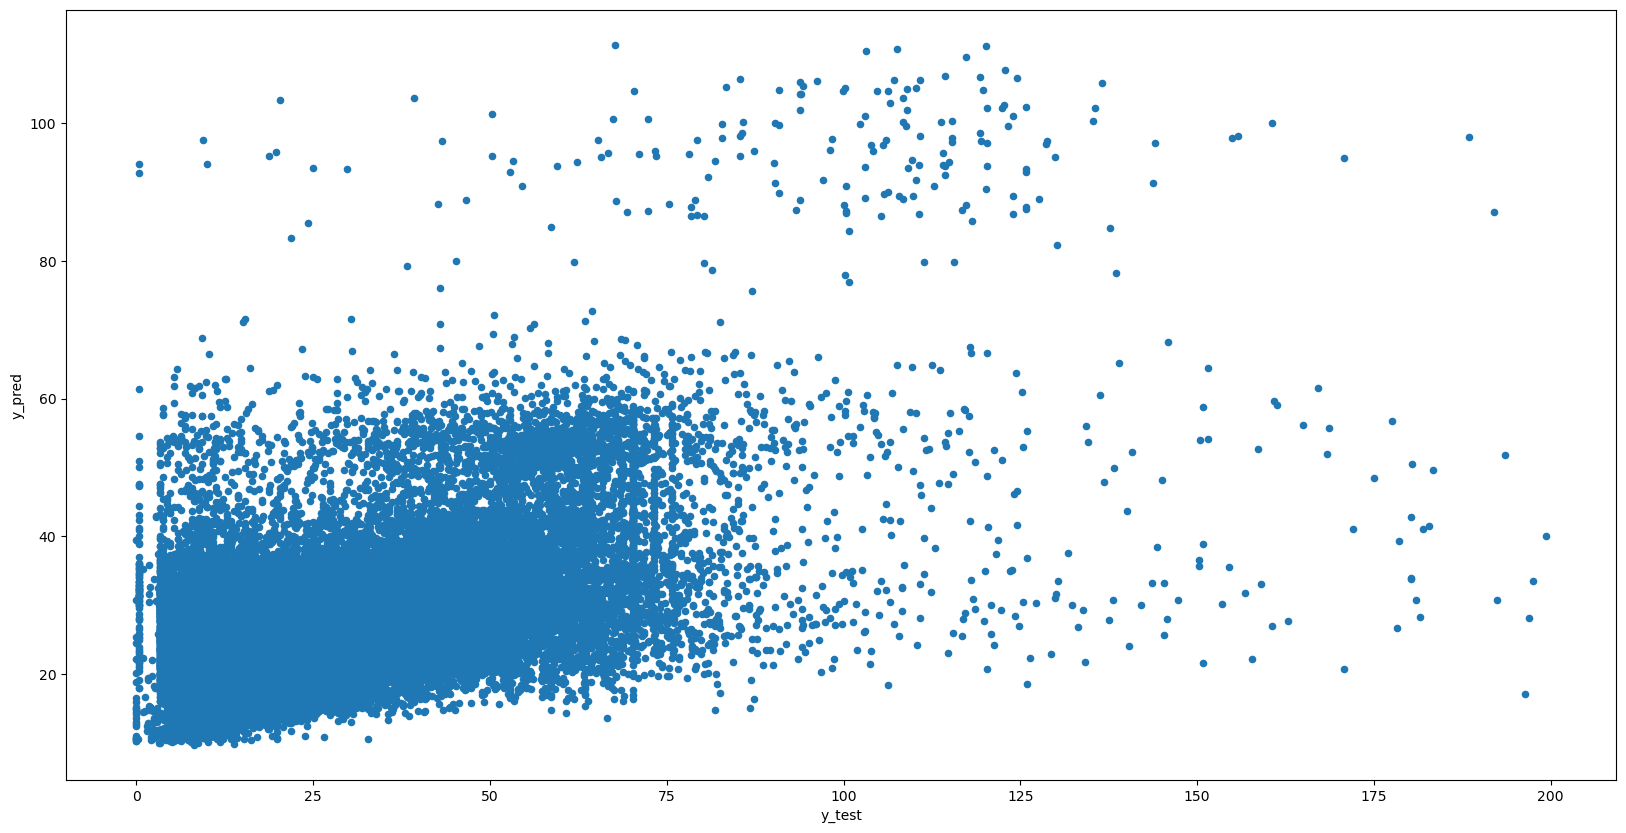

In [264]:
compare_data_3 = {'y_pred': y_pred_3, 'y_test': y_test}

result3 = pd.DataFrame(compare_data_3)
print(result3.head())

result3.plot(kind='scatter', x='y_test', y='y_pred', figsize=(20, 10))
plt.show()